<a href="https://colab.research.google.com/github/Rybus07/in-a-pickle/blob/main/notebooks/03_Preprocessing_Feature_Enginneering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction<a id='introduction'></a>

**Purpose:**

Preprocess data and create features for training.

**Context:**

&emsp; Pickleball is an addictively fun racquet sport combining aspects of tennis, table tennis, and badminton and pickleball players are similarly diverse with players of all ages and all sports backgrounds. Players often spend hours on the courts both playing and socializing between games. A common topic of discussion amongst players is strategy with questions such as

* "Should I be dropping or driving my third shots?"
* "What kind of shots are more common at higher levels of play?"

This project aims to answer common questions in pickleball using data from pklmart.

**Data:**

Collection of pklmart data on Kaggle (https://www.kaggle.com/datasets/cakesofspan/pklmarts-competitive-pickleball-extracts). \
Pklmart (https://pklmart.com/) \
Tutorial for time series forecasting using TensorFlow (https://www.tensorflow.org/tutorials/structured_data/time_series)

**Outcomes from this notebook (Preprocessing and FE):**

1. Preprocessed data further for training
2. Created pipeline which grabs appropriate columns from dataframe and creates train, test splits
3. Trained a model using XGBoost to demonstrate process

**Outcomes from previous notebook (EDA):**

1. Calculated adjacency matrices for my shot vs opponent's shot and my shot vs my next shot
    * While interesting, decided to go elsewhere with the project and pursue sequence prediction. Can come back to this later
2. Fit `rally_len` distributions to weibull distributions and log-normal
    * Lower skill levels are better fit with a weibull distribution
    * high skill levels had a longer tail and are better fit with a log-normal distribution
    * Fitted distributions are nice to have, but moving on with sequence prediction using RNNs
3. Distributions showed trends in skill_lvl where players with skill_lvl of 4.5 and above played similarly and could be grouped into a larger class called 'Advanced'
4. Saw that cardinality of `shot_type` was high and needed to be reduced

## Contents<a id='contents'></a>
* [Introduction](#introduction)
* [Contents](#contents)
* [Objectives](#objectives)
* [Loading Data](#loading_data)
* [Preprocessing Data](#preprocessing_data)
* [Training Example](#training_example)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

# Andy's path to project data folder
data_path = '/content/drive/MyDrive/Colab Notebooks/DSCI 521 Final Project (Pickleball Analytics)/data/'

Mounted at /content/drive


## Objectives

1. Train a classifier to reduce dimensionality of ``shot_type`` down to a list of 10 shots
    - ``['Serve', 'Return', 'Drop', 'Volley', 'Dink', 'Lob', 'Speed Up',
       'Repel', 'Drive', 'Reset']``
2. Hyperparameter tune
3. Evaluate model for each shot type
4. Save new dataframe

## Loading Data<a id='loading_data'></a>

In [ ]:
# resuming from Ryan's FE
pb_df = pd.read_csv(data_path+'processed/clean_mdl_data.csv', index_col=0)
pb_df.head(2)

/tmp/ipykernel_712/2062619860.py:4: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  pb_df = pd.read_csv(data_path+'interim/pre_clean_mdl_data.csv', index_col=0)


,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,skill_Intermediate,skill_Pro,team_hitting,next_loc_x_missing,next_loc_y_missing,delta_x_loc_missing,delta_y_loc_missing,shot_distance_missing,shot_angle_missing,shot_type_bins
0,290875,M10,G18,R814,1,5,T13,T14,T14,S8558,...,0,1,1,0,0,0,0,0,0,Serve
1,290876,M10,G18,R814,1,5,T13,T14,T14,S8559,...,0,1,0,0,0,0,0,0,0,Return


## Preprocessing Data<a id='preprocessing_data'></a>

For preprocessing:
1. Mapping `shot_type` from codes to English
2. Mapping `skill_lvl` to `['Beginner', 'Intermediate', 'Advanced']`
3. Force all first shots to be of type Serve and all second shots to be of type Return
4. Reorder and slice dataframe

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
def reformat_data(df):
    '''
    Reformating and cleaning data one last time before feeding it into the preprocessing pipeline
    Steps taken:
    1. Mapping shot_type codes to english
    2. Mapping skill level into 3 bins beginner, intermediate, advanced
    3. Force all first and second shots to be serve and return, respectively
    4. Reorder and slice dataframe
    '''
    # Step 1. mapping shot_type codes to english
    # while manually Erne and ATP to Volley and Speed Up
    mapper = {'D':'Dink', 'HB':'Volley', 'SE':'Serve', 'R':'Return',
              'tzRep':'Repel', 'tzApp':'tzApp', 'tsDrp':'Drop', 'tsDrv':'Drive',
              'SP':'Speed Up', 'Res':'Reset', 'U':'U', 'L':'Lob', 'tsLob':'Lob',
              'E':'Volley', 'A':'Speed Up', 'O':'O', 'ball':'ball'}

    df['shot_type'] = df['shot_type_y'].map(mapper)

    # Step 2. mapping skill level into 3 bins beginner, intermediate, advanced
    skill_mapper = {'2.5':'Beginner', '3.0':'Beginner', '3.5':'Intermediate',
                    '4.0':'Intermediate', '4.0':'Advanced', '4.5':'Advanced',
                    '5.0':'Advanced', '5.5':'Advanced', 'Pro':'Advanced', 'Senior Pro':'Advanced'}

    df['skill_lvl'] = df['skill_lvl'].map(skill_mapper)

    # Step 3. Force all first and second shots to be serve, return, respectively
    df.loc[df.shot_nbr == 1, 'shot_type'] = 'Serve'
    df.loc[df.shot_nbr == 2, 'shot_type'] = 'Return'

    # Step 4. Reorder and slice dataframe
    df.rename(columns={'delta_x_loc':'delta_loc_x', 'delta_y_loc':'delta_loc_y'},
              inplace=True)
    new_order = ['rally_id', 'rally_nbr', 'rally_len', 'skill_lvl', 'shot_nbr',
                'shot_type', 'loc_x', 'loc_y', 'next_loc_x', 'next_loc_y',
                'delta_loc_x', 'delta_loc_y', 'shot_distance', 'shot_angle',
                'srv_point_won', 'team_hitting']
    df = df[new_order]

    return df

In [ ]:
def gen_preprocess_pipe():
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    cat_cols = ['skill_lvl']
    num_cols = ['loc_x', 'loc_y', 'next_loc_x', 'next_loc_y',
                'delta_loc_x', 'delta_loc_y', 'shot_distance', 'shot_angle']

    transformer = ColumnTransformer([
        ('cat_trans', ohe, cat_cols),
        ('num_trans', 'passthrough', num_cols)
    ])
    pipe = Pipeline([
        ('col_trans', transformer),
        ('scaler', StandardScaler())
    ])
    return pipe

def add_col_names(pipe, df):
    '''
    Called after fitting pipe
    '''
    cols = list(pipe['col_trans']['cat_trans'].get_feature_names_out())
    cols.extend(list(pipe['col_trans']['num_trans'].get_feature_names_out()))

    df = pd.DataFrame(df, columns=cols)
    return df

In [ ]:
def create_splits(df, splits=(0.9, 0.1), seed=42):
    known_shots = ['Drop', 'Volley', 'Dink', 'Lob', 'Speed Up', 'Repel', 'Drive', 'Reset']
    known_mask = [True if x in known_shots else False for x in df.shot_type]
    unknown_shots = ['U', 'tzApp', 'ball', 'O']
    unknown_mask = [True if x in unknown_shots else False for x in df.shot_type]

    X = df[known_mask]
    y = X.shot_type
    X_unknown = df[unknown_mask]

    x_train, x_test, y_train, y_test = train_test_split(X, y,
                                    train_size=splits[0],
                                    random_state=seed)

    pipe = gen_preprocess_pipe()
    x_train = pipe.fit_transform(x_train)
    x_test = pipe.transform(x_test)

    x_train = add_col_names(pipe, x_train)
    x_test = add_col_names(pipe, x_test)

    X_unknown = pipe.transform(X_unknown)
    X_unknown = add_col_names(pipe, X_unknown)

    return x_train, x_test, y_train, y_test, X_unknown

## Training Example<a id='training_example'></a>

Trained using XGBoost. Explored confusion matrix and feature importance.

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

In [ ]:
pb_df = reformat_dat(pd_df)

x_train, x_test, y_train, y_test, X_unknown = create_splits(pb_df, splits=(0.8, 0.2), seed=0)

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [ ]:
xgb_model = xgb.XGBClassifier(
    tree_method='hist',
    device="cuda",
    objective='multi:softmax',
    num_class=10,
    eval_metric='mlogloss',
    random_state=42
)

param_grid = {
    'n_estimators': [600, 650, 700],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=skf,
    verbose=1
)

grid_search.fit(x_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_:.4f}")

best_xgb = grid_search.best_estimator_

Fitting 6 folds for each of 9 candidates, totalling 54 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [17:15:39] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 650, 'subsample': 0.8}
Best Score: 0.6276


In [ ]:
from sklearn.metrics import f1_score

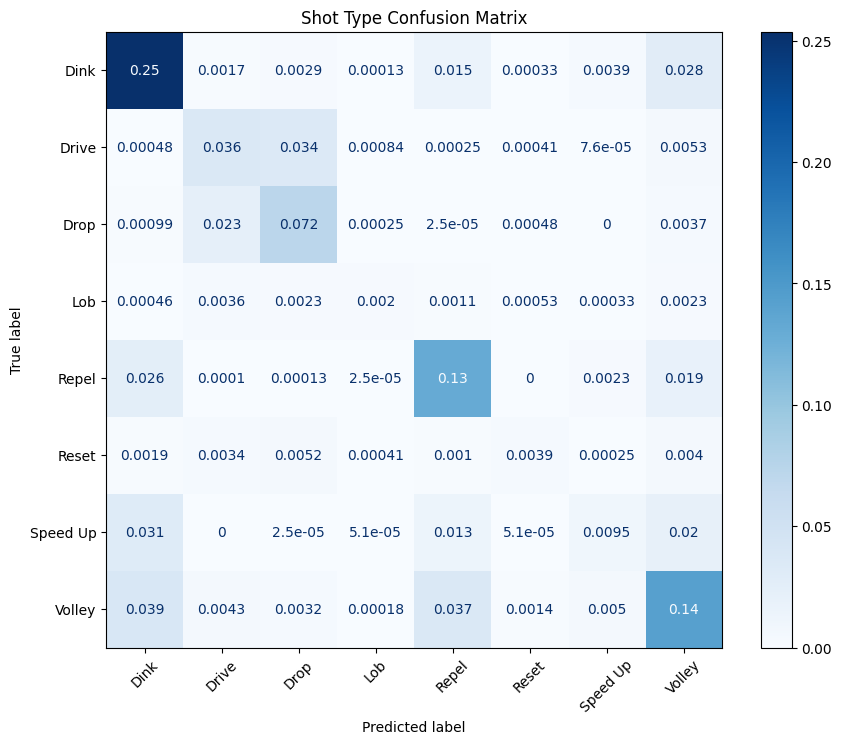

In [ ]:
# show confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_predicted = best_xgb.predict(x_test)
cm = confusion_matrix(y_test, y_predicted)

cm = cm/cm.sum().sum()

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Shot Type Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Drive, Lob, Reset, Speed Up
print(classification_report(y_test, y_predicted, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

        Dink       0.72      0.83      0.77     12015
       Drive       0.51      0.46      0.48      3048
        Drop       0.60      0.73      0.66      3942
         Lob       0.50      0.15      0.23       499
       Repel       0.66      0.73      0.69      6966
       Reset       0.57      0.20      0.30       790
    Speed Up       0.44      0.12      0.19      2913
      Volley       0.63      0.61      0.62      9113

    accuracy                           0.65     39286
   macro avg       0.58      0.48      0.49     39286
weighted avg       0.63      0.65      0.63     39286



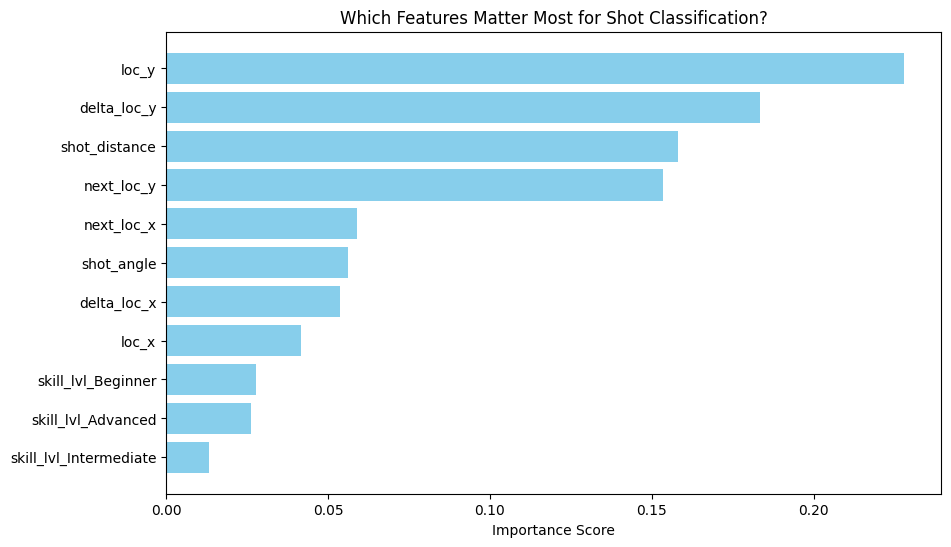

In [ ]:
# Get feature importance
importances = grid_search.best_estimator_.feature_importances_
features = x_train.columns

feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Which Features Matter Most for Shot Classification?')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Decent spread
y_unknown = best_xgb.predict(X_unknown)
y_unknown = label_encoder.inverse_transform(y_unknown)
Counter(y_unknown)

Counter({'Dink': 4171,
         'Volley': 8469,
         'Drop': 9499,
         'Lob': 424,
         'Drive': 4791,
         'Reset': 921,
         'Repel': 936,
         'Speed Up': 120})